In [1]:
# standard libraries
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.linalg import expm, logm
from scipy.optimize import minimize
from scipy.stats import gaussian_kde
from sklearn.manifold import MDS

In [2]:
# custom libraries
from visualization import plot_network
from bsa import NetBSA
from tangent_pca import NetPCA
from topologies import complete_graph, star_graph, star_2_graph

In [3]:
def spectral_dist(point_a, point_b):
    val_a, vec_a = np.linalg.eigh(point_a)
    val_b, vec_b = np.linalg.eigh(point_b)
    return(np.linalg.norm(val_b - val_a))

In [4]:
import warnings
warnings.filterwarnings('ignore')

# 4 - A comparison with tangent principal component analysis

In [5]:
with open('Datasets/bsa_vs_pca.npy', 'rb') as file: dataset = np.load(file)

In [6]:
n_samples, n_nodes = dataset.shape[0], dataset.shape[1]

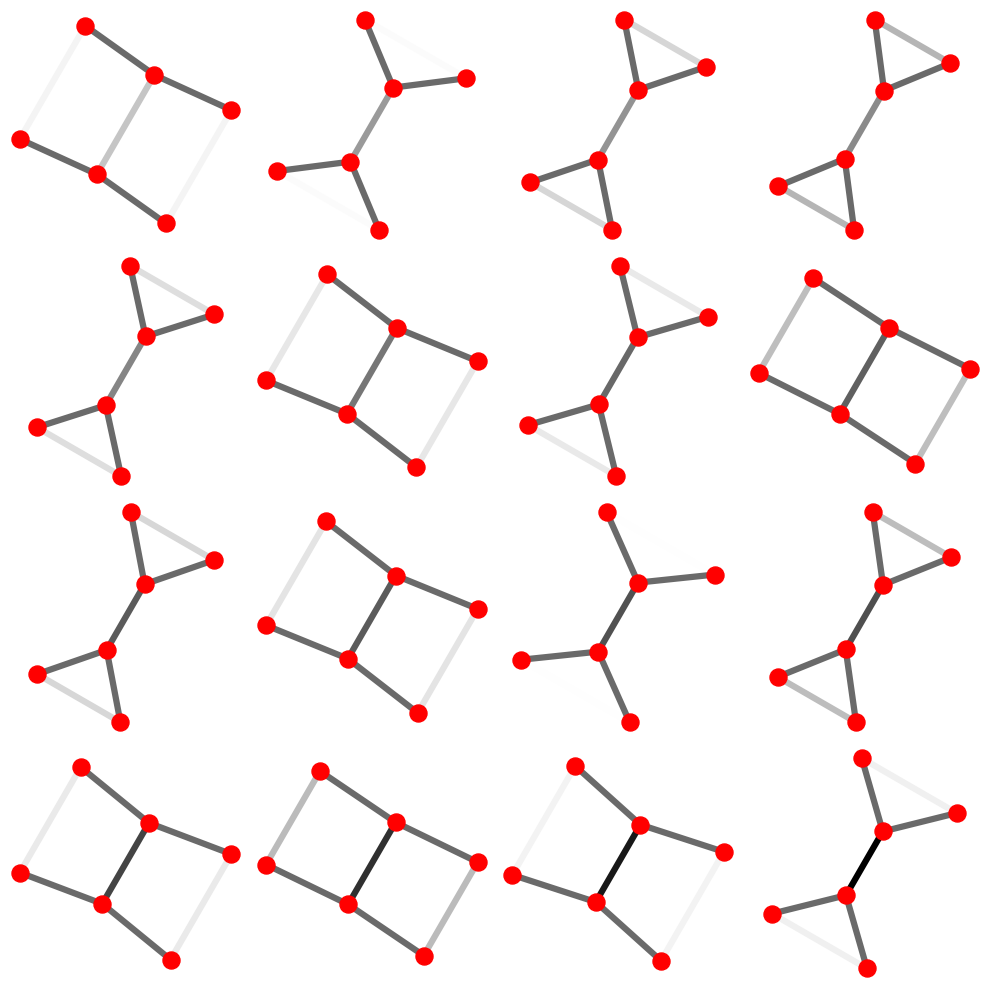

In [7]:
fig = plt.figure(figsize=(10, 10))

for (i, X) in enumerate(dataset):
    ax = plt.subplot(4, 4, i + 1)
    plot_network(ax, X, x_max=np.max(dataset))
    plt.axis('equal')
    plt.axis('off')
    
fig.tight_layout()

#### Tangent PCA

In [8]:
pca = NetPCA(n_nodes=n_nodes)

||jac|| = 1.3777680143756674e-16


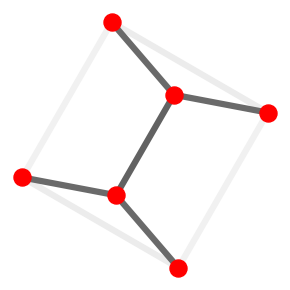

In [9]:
mean, jac, success = pca._frechet_mean(dataset)
print("||jac|| =", jac)

fig = plt.figure(figsize=(3, 3))
ax = plt.axes()

plot_network(ax, mean, x_max=np.max(dataset))

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

In [10]:
dataset_transformed, components, var, var_ratio = pca.tangent_pca(dataset, n_components=2, fast=False)
print('explained variance ratios:', var_ratio)

explained variance ratios: [0.57056159 0.31241159]


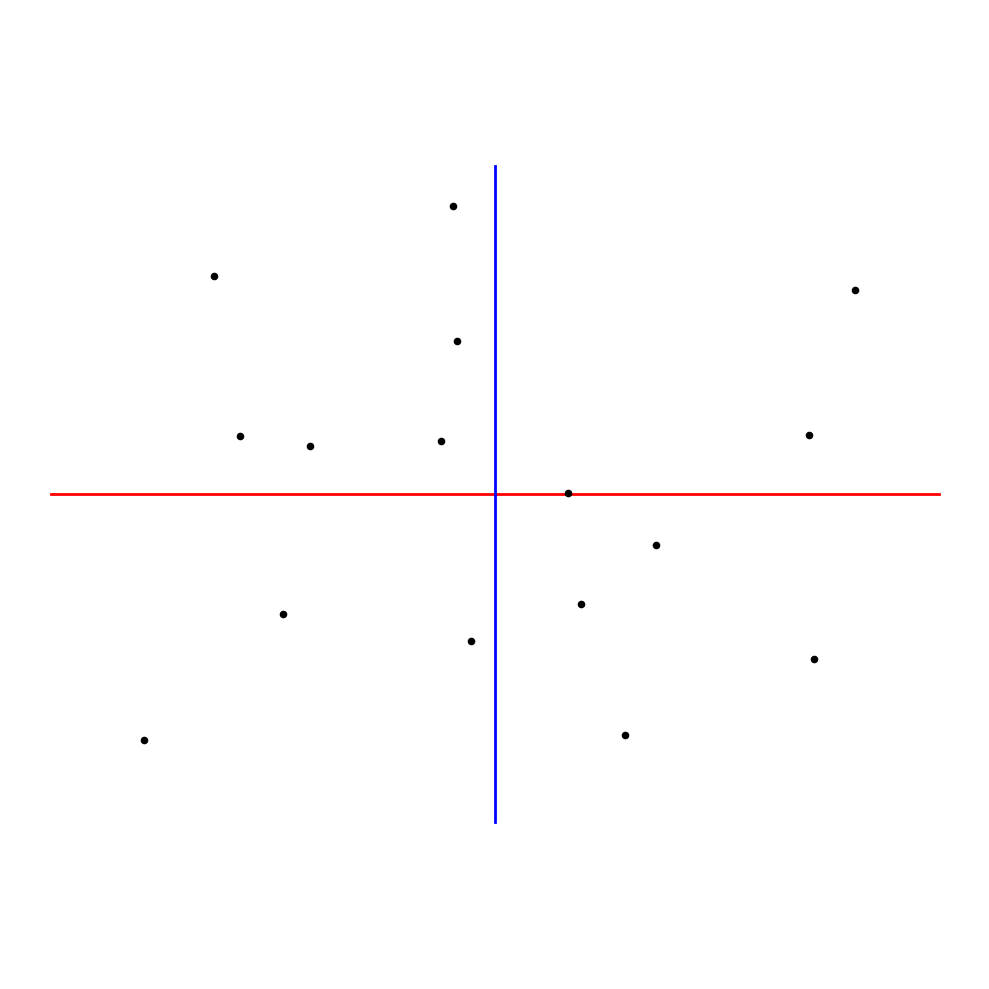

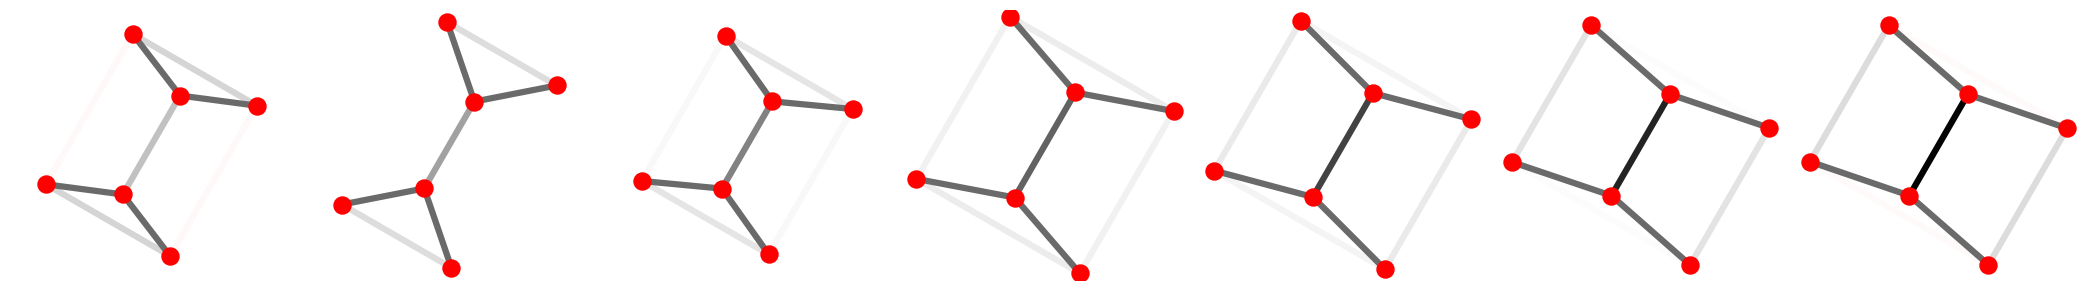

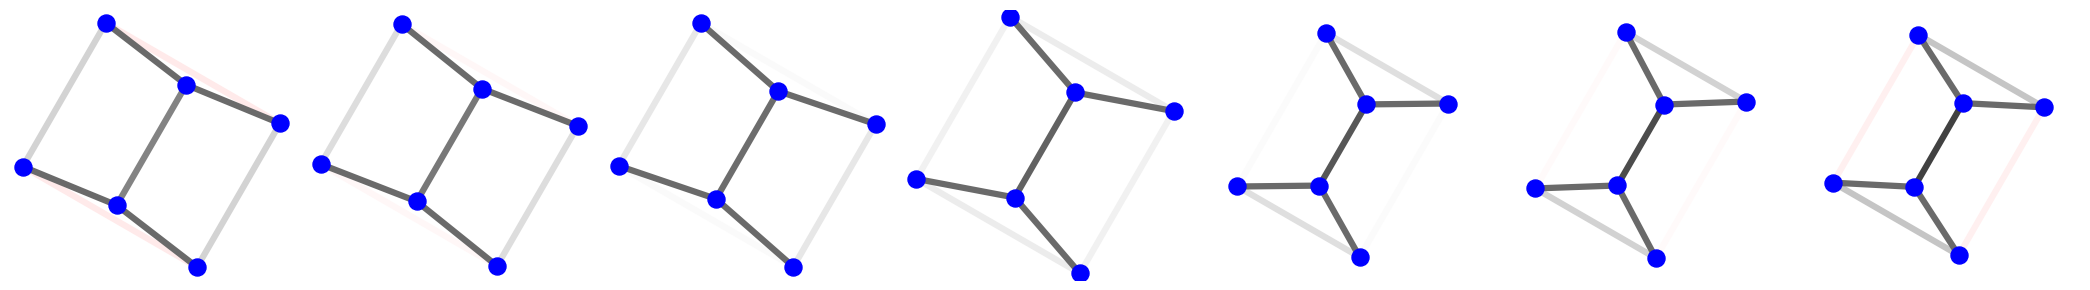

In [11]:
fig = plt.figure(figsize=(10, 10))

plt.scatter(dataset_transformed[:, 0], dataset_transformed[:, 1], c='k', s=20)
plt.plot(np.linspace(-2. * np.sqrt(var[0]), 2. * np.sqrt(var[0]), 2), np.zeros(2), 'r-', lw=2, zorder=-1)
plt.plot(np.zeros(2), np.linspace(-2. * np.sqrt(var[1]), 2. * np.sqrt(var[1]), 2), 'b-', lw=2, zorder=-1)

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

components = (np.abs(components) > 1E-12) * components #removing loop artefacts

fig = plt.figure(figsize=(21, 3))

for (i, X) in enumerate(np.linspace(-2. * np.sqrt(var[0]), 2. * np.sqrt(var[0]), 7)):
    ax = plt.subplot(1, 7, i+1)
    plot_network(ax, mean + X * components[0].reshape(mean.shape), node_color='r', x_max=np.max(dataset))
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()

fig = plt.figure(figsize=(21, 3))

for (i, X) in enumerate(np.linspace(-2. * np.sqrt(var[1]), 2. * np.sqrt(var[1]), 7)):
    ax = plt.subplot(1, 7, i+1)
    plot_network(ax, mean + X * components[1].reshape(mean.shape), node_color='b', x_max=np.max(dataset))
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()

In [12]:
projection_error = 0

for i in range(n_samples):
    X = mean + dataset_transformed[i, 0] * components[0].reshape(mean.shape) + dataset_transformed[i, 1] * components[1].reshape(mean.shape)
    projection_error += np.linalg.norm(dataset[i] - X) ** 2
    
print('mse =',  projection_error / n_samples)

mse = 0.04739978650190036


#### BSA

In [13]:
bsa = NetBSA(n_nodes=n_nodes, k_ref=3)
ref_samples, weights, total_error = bsa._bsa(dataset, k_ref=3)
print("reference networks:", ref_samples)
print("mse:", total_error / n_samples)

reference networks: [5, 9, 11]
mse: 0.03407797738398495


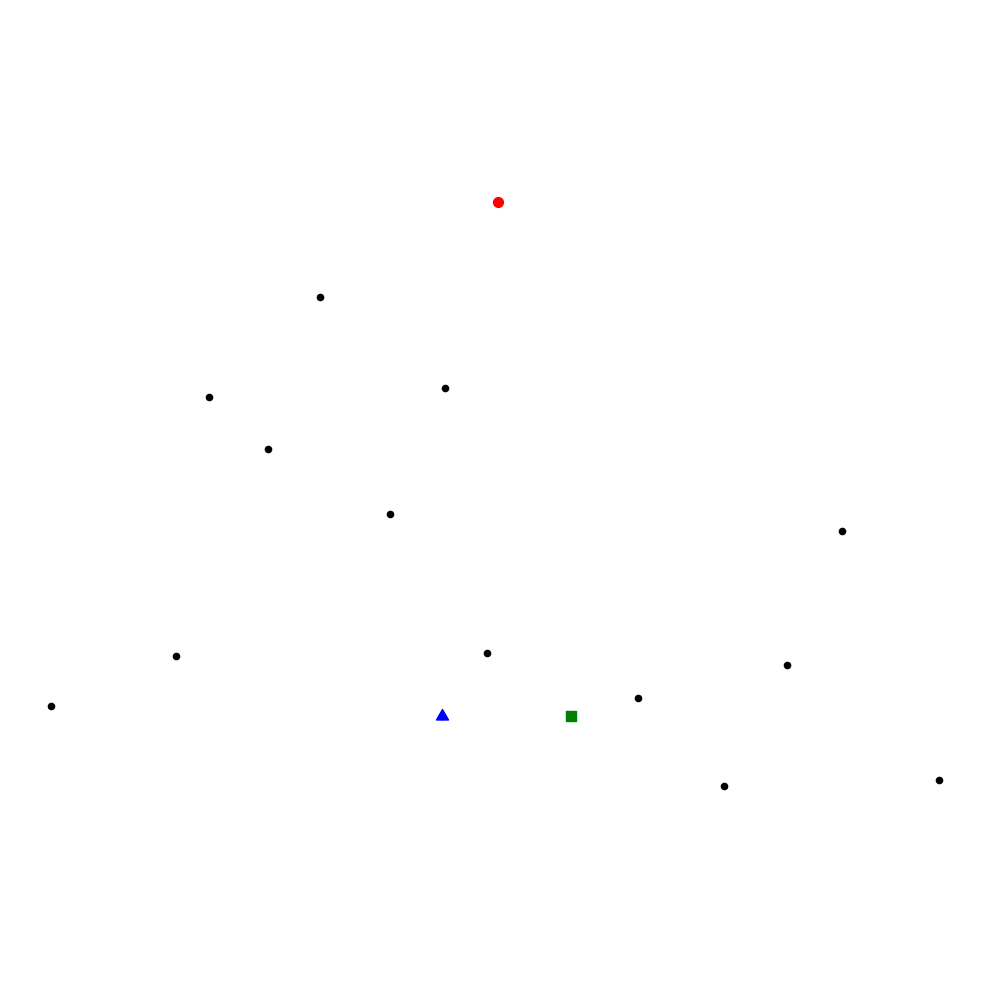

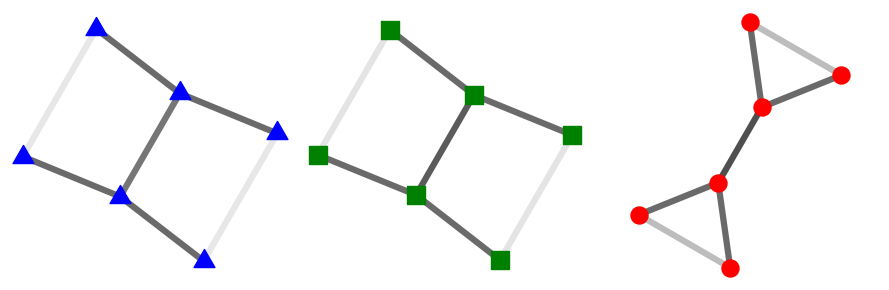

In [14]:
dataset_transformed = bsa._visualize_2d(dataset, dataset[ref_samples], weights)

ref_colors = ['b', 'g', 'r']
ref_markers = [(3, 0, 0), 's', 'o']
ref_sizes = [300, 150, 150]

fig = plt.figure(figsize=(10, 10))

for l, i_l in enumerate(ref_samples): plt.scatter(dataset_transformed[i_l, 0], dataset_transformed[i_l, 1], s=ref_sizes[l] / 3., c=ref_colors[l], marker=ref_markers[l], zorder=2)
plt.scatter(dataset_transformed[:, 0], dataset_transformed[:, 1], c='k', s=20)

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

fig = plt.figure(figsize=(bsa.k_ref * 3, 3))

for (l, i_l) in enumerate(ref_samples):
    ax = plt.subplot(1, bsa.k_ref, l+1)
    plot_network(ax, dataset[i_l], s=ref_sizes[l], node_color=ref_colors[l], m=ref_markers[l], x_max=np.max(dataset))
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()

#### Convex BSA

In [15]:
ref_samples, weights, total_error = bsa._convex_bsa(dataset, k_ref=3)
print("reference networks:", ref_samples)
print("mse:", total_error / n_samples)

reference networks: [1, 11, 13]
mse: 0.05204201777845499


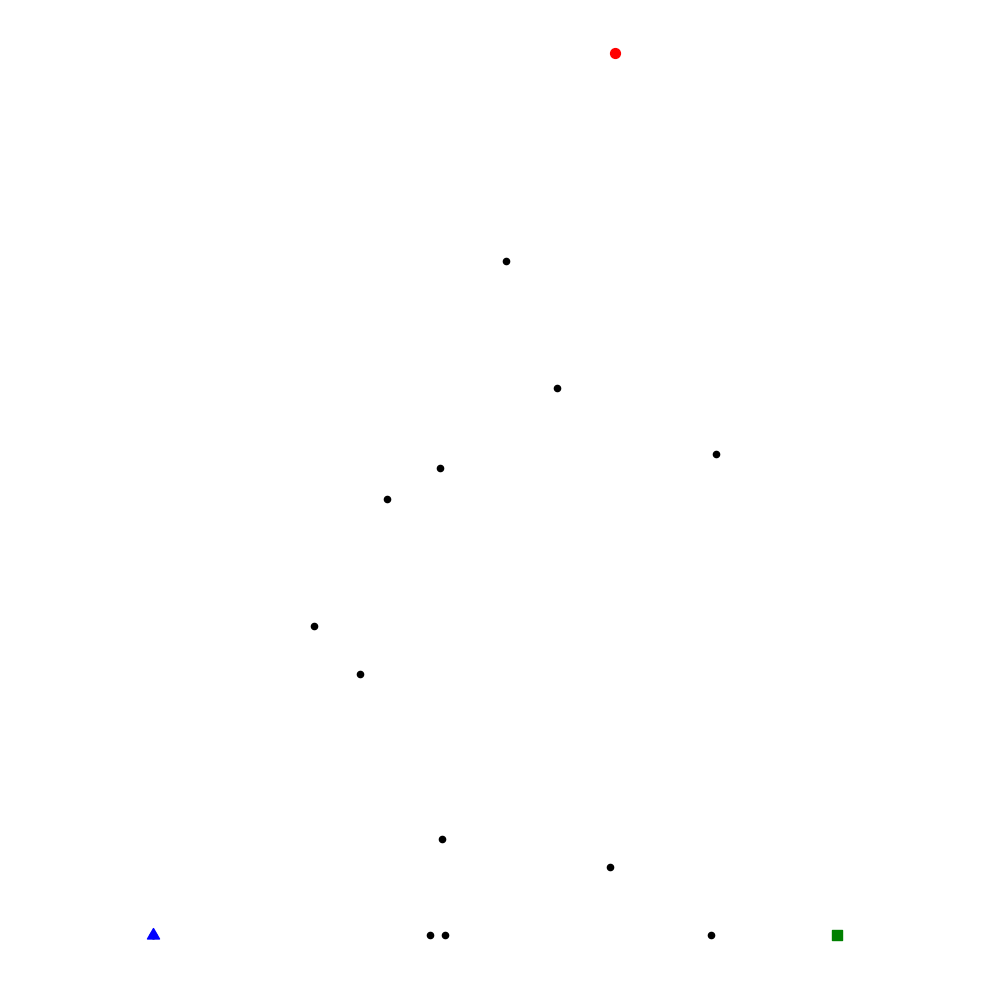

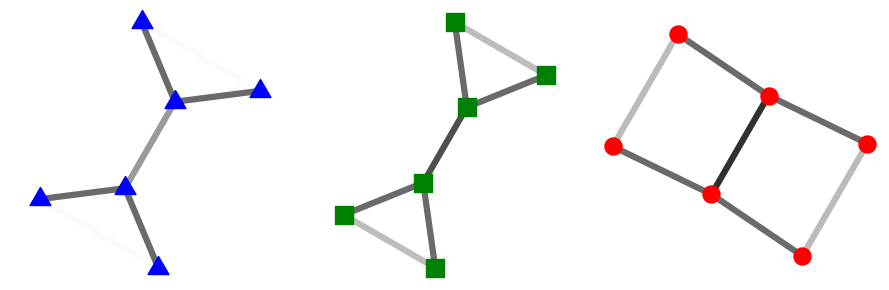

In [16]:
dataset_transformed = bsa._visualize_2d(dataset, dataset[ref_samples], weights)

ref_colors = ['b', 'g', 'r']
ref_markers = [(3, 0, 0), 's', 'o']
ref_sizes = [300, 150, 150]

fig = plt.figure(figsize=(10, 10))

for l, i_l in enumerate(ref_samples): plt.scatter(dataset_transformed[i_l, 0], dataset_transformed[i_l, 1], s=ref_sizes[l] / 3., c=ref_colors[l], marker=ref_markers[l], zorder=2)
plt.scatter(dataset_transformed[:, 0], dataset_transformed[:, 1], c='k', s=20)

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

fig = plt.figure(figsize=(bsa.k_ref * 3, 3))

for (l, i_l) in enumerate(ref_samples):
    ax = plt.subplot(1, bsa.k_ref, l+1)
    plot_network(ax, dataset[i_l], s=ref_sizes[l], node_color=ref_colors[l], m=ref_markers[l], x_max=np.max(dataset))
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()

# 5 - A small case study on European airlines route maps

In [17]:
with open('Datasets/airlines.npy', 'rb') as file: dataset = np.load(file)

In [18]:
n_samples, n_nodes = dataset.shape[0], dataset.shape[1]

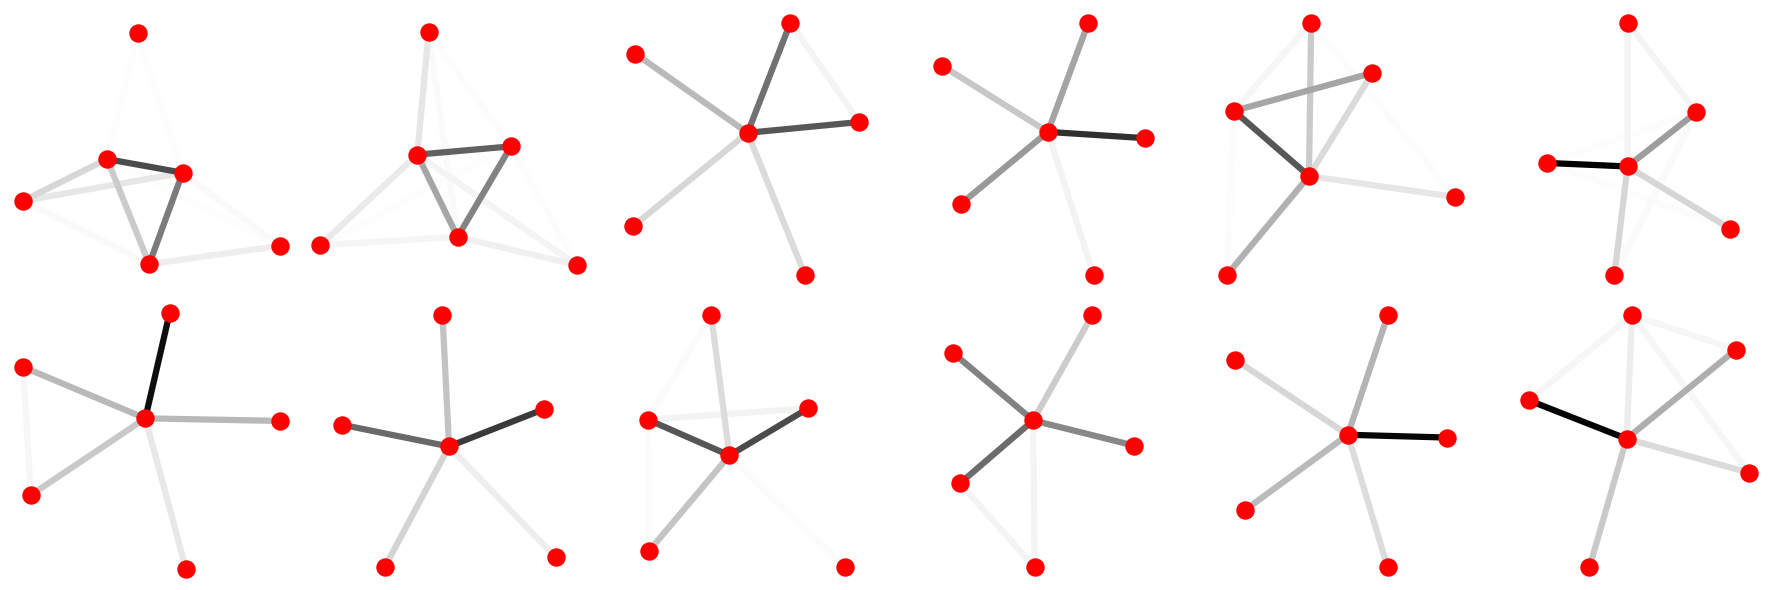

In [19]:
fig = plt.figure(figsize=(18, 6))

for (i, X) in enumerate(dataset):
    ax = plt.subplot(2, 6, i+1)
    plot_network(ax, X, x_max = np.max(dataset))
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()

In [20]:
bsa = NetBSA(n_nodes=n_nodes, k_ref=2)

In [21]:
ref_samples_seq, weights_seq, total_error_seq = bsa._forward_convex_bsa(dataset)

2
3
4
5
6
7
8
9
10
11


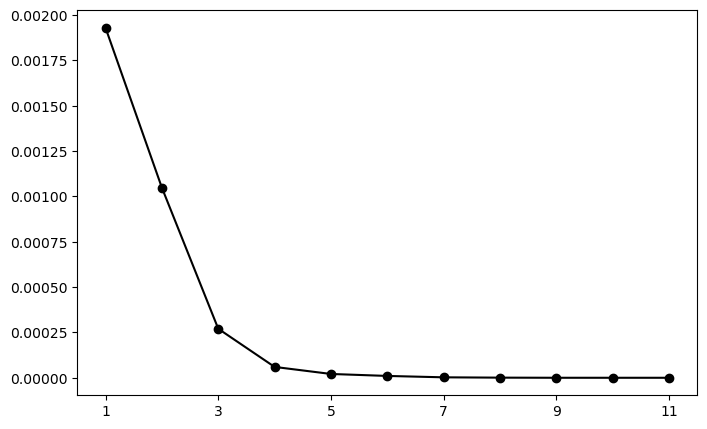

In [22]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.plot(np.arange(1, len(total_error_seq)+1), [max(1E-12, e) for e in np.array(total_error_seq) / n_samples], 'ko-')
xticks = np.arange(1, len(total_error_seq)+1, 2)
ax.set_xticks(xticks);

In [23]:
ref_samples_seq, weights_seq, total_error_seq = bsa._backward_convex_bsa(dataset, ref_samples_init=ref_samples_seq[7])

9
8
7
6
5
4
3
2


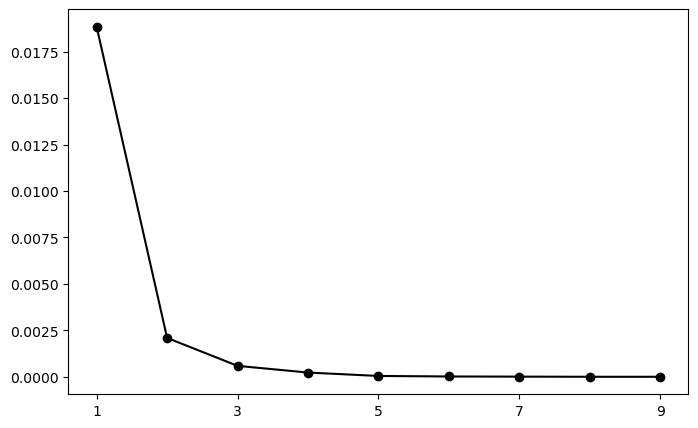

In [24]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.plot(np.arange(1, len(total_error_seq)+1), [max(1E-12, e) for e in np.array(total_error_seq) / n_samples], 'ko-')
xticks = np.arange(1, len(total_error_seq)+1, 2)
ax.set_xticks(xticks);

In [25]:
k_ref = 2

In [26]:
ref_samples = ref_samples_seq[k_ref-1]
weights = weights_seq[k_ref-1]
total_error = total_error_seq[k_ref-1]
print("reference networks:", [int(i) for i in ref_samples])
print("mse:", total_error / n_samples)

reference networks: [1, 10]
mse: 0.0020918017535727445


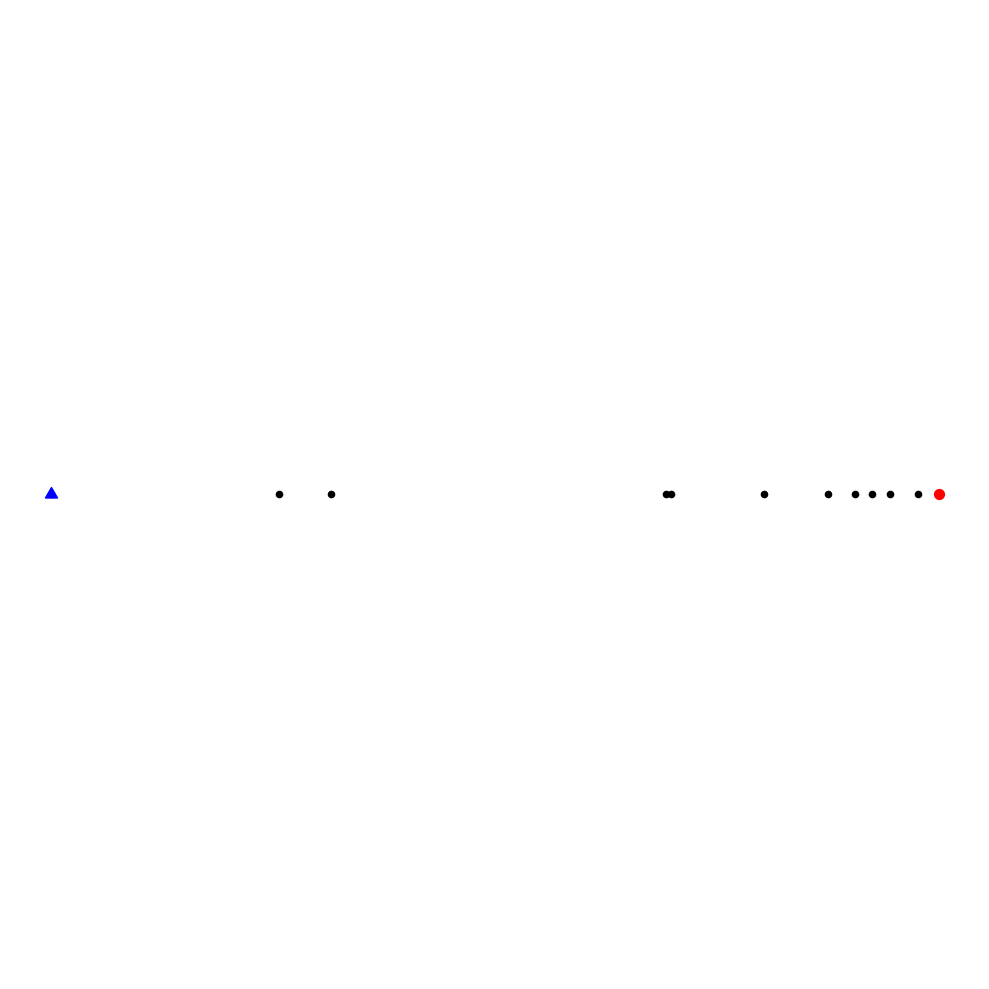

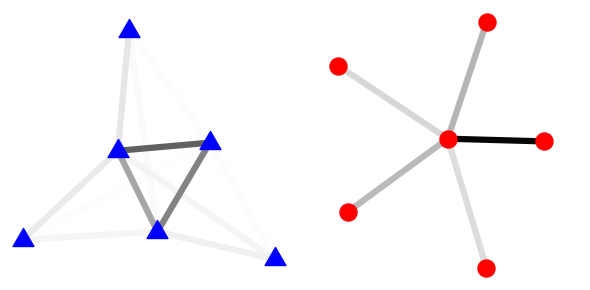

In [27]:
dataset_transformed = bsa._visualize_2d(dataset, dataset[ref_samples], weights)

ref_colors = ['b', 'r']
ref_markers = [(3, 0, 0), 'o']
ref_sizes = [300, 150]

fig = plt.figure(figsize=(10, 10))

for l, i_l in enumerate(ref_samples): plt.scatter(dataset_transformed[i_l, 0], dataset_transformed[i_l, 1], s=ref_sizes[l] / 3., c=ref_colors[l], marker=ref_markers[l], zorder=2)
plt.scatter(dataset_transformed[:, 0], dataset_transformed[:, 1], c='k', s=20)

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

fig = plt.figure(figsize=(k_ref * 3 , 3))

for (l, i_l) in enumerate(ref_samples):
    ax = plt.subplot(1, k_ref, l+1)
    plot_network(ax, dataset[i_l], s=ref_sizes[l], node_color=ref_colors[l], m=ref_markers[l], x_max=np.max(dataset))
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()

# 6 - Application to brain EEG functional connectivity networks

### Read data

In [28]:
stimulus = 'S1obj'
# stimulus = 'S2match'
# stimulus = 'S2nomatch'

In [29]:
with open(f'Datasets/eeg_{stimulus}-networks.npy', 'rb') as file: dataset = np.load(file)
with open(f'Datasets/eeg_{stimulus}-group_labels.npy', 'rb') as file: group_labels = np.load(file)

In [30]:
n_samples, n_nodes = dataset.shape[0], dataset.shape[1]

### Analysis

In [31]:
visualization = 'network'

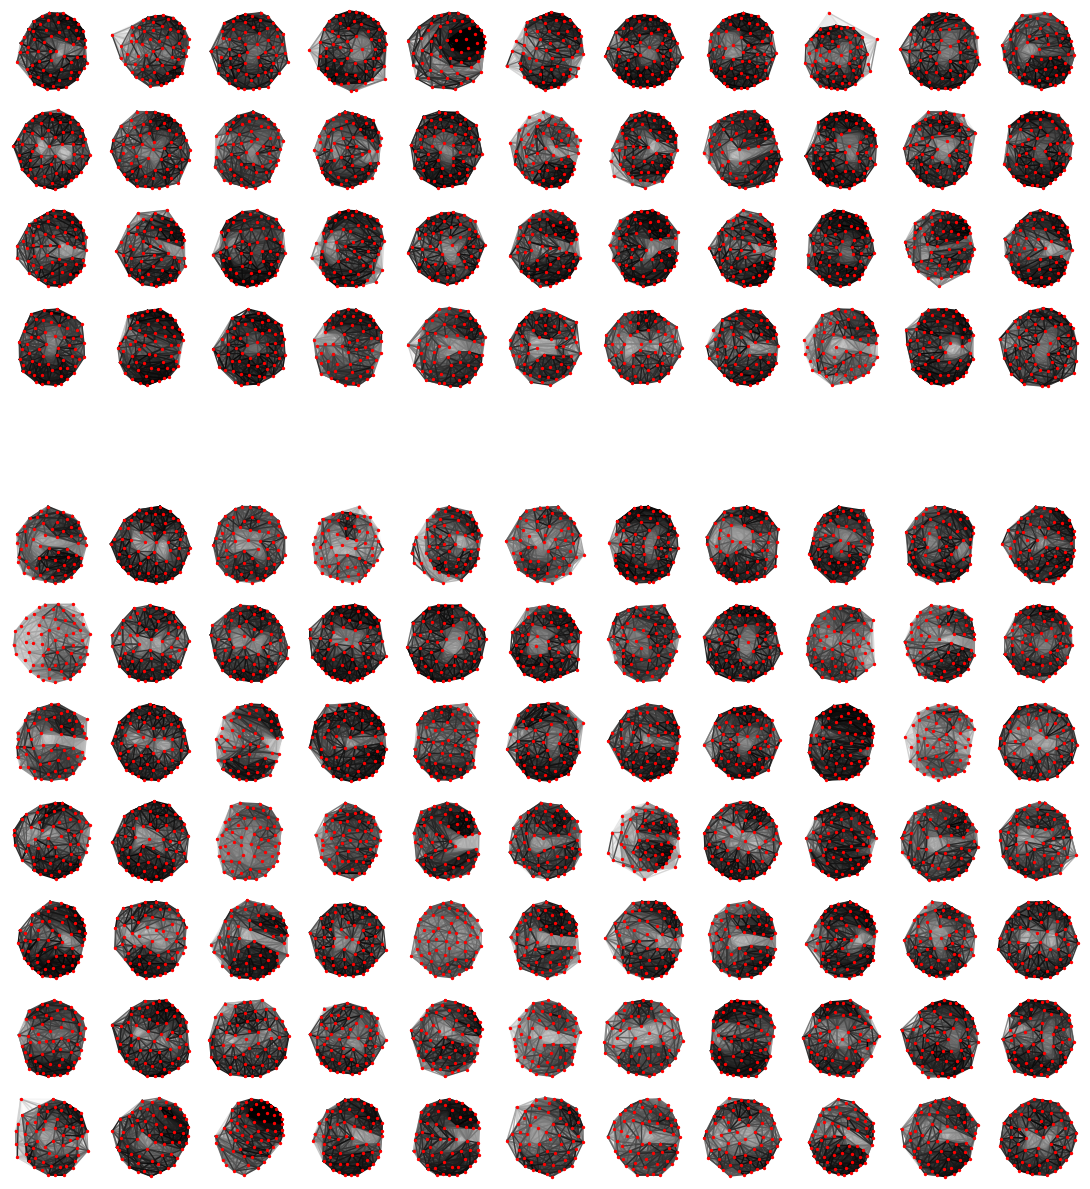

In [32]:
control = [i for i in range(n_samples) if group_labels[i] == 'c']
alcoholic = [i for i in range(n_samples) if group_labels[i] == 'a']

fig = plt.figure(figsize=(11, 12))

for k, i in enumerate(control):
    ax = plt.subplot(12, 11, k+1)
    if visualization == 'network': plot_network(ax, dataset[i], s=2, node_color='r', edge_width=1, x_max=1.)
    if visualization == 'matrix': ax.imshow(dataset[i], cmap='viridis', interpolation='nearest', vmin=0., vmax=1.)
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()

for k, i in enumerate(alcoholic):
    ax = plt.subplot(12, 11, 55+k+1)
    if visualization == 'network': plot_network(ax, dataset[i], s=2, node_color='r', edge_width=1, x_max=1.)
    if visualization == 'matrix': ax.imshow(dataset[i], cmap='viridis', interpolation='nearest', vmin=0., vmax=1.)
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()
plt.show()

In [33]:
spectra = np.linalg.eigvalsh(dataset)
outliers = [i for i in range(n_samples) if np.quantile(np.linalg.norm(spectra[i] - spectra, axis=1), .05) > 5.]
n_outliers = len(outliers)
dataset_without_outliers = np.array([dataset[i] for i in range(n_samples) if i not in outliers])

In [34]:
bsa = NetBSA(n_nodes=dataset_without_outliers[0].shape[0], k_ref=3)

In [35]:
ref_samples_seq, weights_seq, total_error_seq = bsa._forward_convex_bsa(dataset_without_outliers, k_max=20)

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


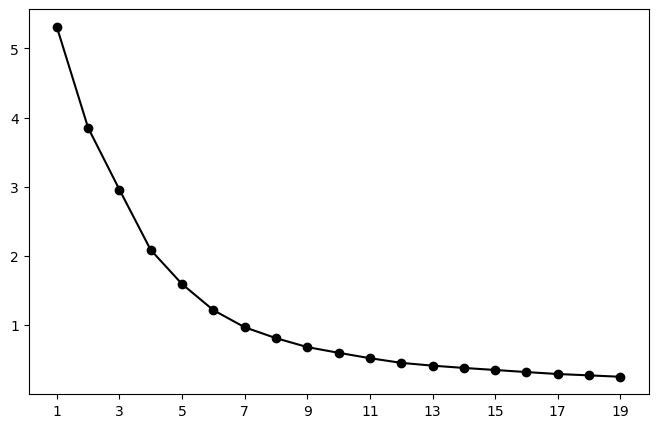

In [36]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.plot(np.arange(1, len(total_error_seq)+1), [max(1E-12, e) for e in np.array(total_error_seq) / (n_samples - n_outliers)], 'ko-')
xticks = np.arange(1, len(total_error_seq)+1, 2)
ax.set_xticks(xticks);

In [37]:
ref_samples_seq, weights_seq, total_error_seq = bsa._backward_convex_bsa(dataset_without_outliers, ref_samples_init=ref_samples_seq[-1])

20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2


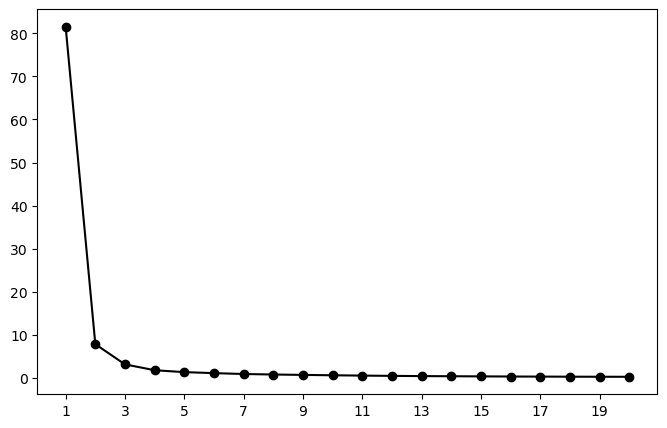

In [38]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.plot(np.arange(1, len(total_error_seq)+1), [max(1E-12, e) for e in np.array(total_error_seq) / (n_samples - n_outliers)], 'ko-')
xticks = np.arange(1, len(total_error_seq)+1, 2)
ax.set_xticks(xticks);

In [39]:
k_ref = 3

In [40]:
ref_samples = ref_samples_seq[k_ref-1]
weights = weights_seq[k_ref-1]
total_error = total_error_seq[k_ref-1]
print("reference networks:", [int(i) for i in ref_samples])
print("mse:", total_error / (n_samples - n_outliers))

reference networks: [38, 6, 49]
mse: 3.1333860592245393


In [41]:
#colors
group_labels_without_outliers = [group_labels[i] for i in range(n_samples) if i not in outliers]

colors = []
edgecolors = []
for label in group_labels_without_outliers:
    if label == 'c': colors.append((0., 0., 0.)); edgecolors.append('none')
    if label == 'a': colors.append((1., 1., 1.)); edgecolors.append('k')
colors = np.array(colors)
edgecolors = np.array(edgecolors)

cmap_c = mcolors.LinearSegmentedColormap.from_list('black', ['w', (1., .25, .25)])
cmap_a = mcolors.LinearSegmentedColormap.from_list('red', ['w', (.25, .25, 1.)])

ref_colors = ['g', 'b', 'r', 'y']
ref_markers = ['s', (3, 0, 0), 'o', (5, 0, 0)]
ref_sizes = [50, 100, 50, 100]

In [42]:
dataset_transformed = bsa._visualize_2d(dataset_without_outliers, dataset_without_outliers[ref_samples], weights)

In [43]:
# kde
xmin, xmax = np.min(dataset_transformed[:, 0]) - .5, np.max(dataset_transformed[:, 0]) + .5
ymin, ymax = np.min(dataset_transformed[:, 1]) - .5, np.max(dataset_transformed[:, 1]) + .5
Lx, Ly = xmax - xmin, ymax - ymin
step = .05
X, Y = np.meshgrid(np.linspace(xmin - Lx / 10., xmax + Lx / 10., int(Lx / step)), np.linspace(ymin - Ly / 10., ymax + Ly / 10., int(Ly / step)))
kernel_c = gaussian_kde(dataset_transformed[[i for i in range(n_samples - n_outliers) if group_labels_without_outliers[i] == 'c']].T)
kernel_a = gaussian_kde(dataset_transformed[[i for i in range(n_samples - n_outliers) if group_labels_without_outliers[i] == 'a']].T)
Z_c = np.reshape(kernel_c(np.vstack([X.ravel(), Y.ravel()])), X.shape)
Z_a = np.reshape(kernel_a(np.vstack([X.ravel(), Y.ravel()])), X.shape)
Zmax = max(np.max(Z_c), np.max(Z_a))

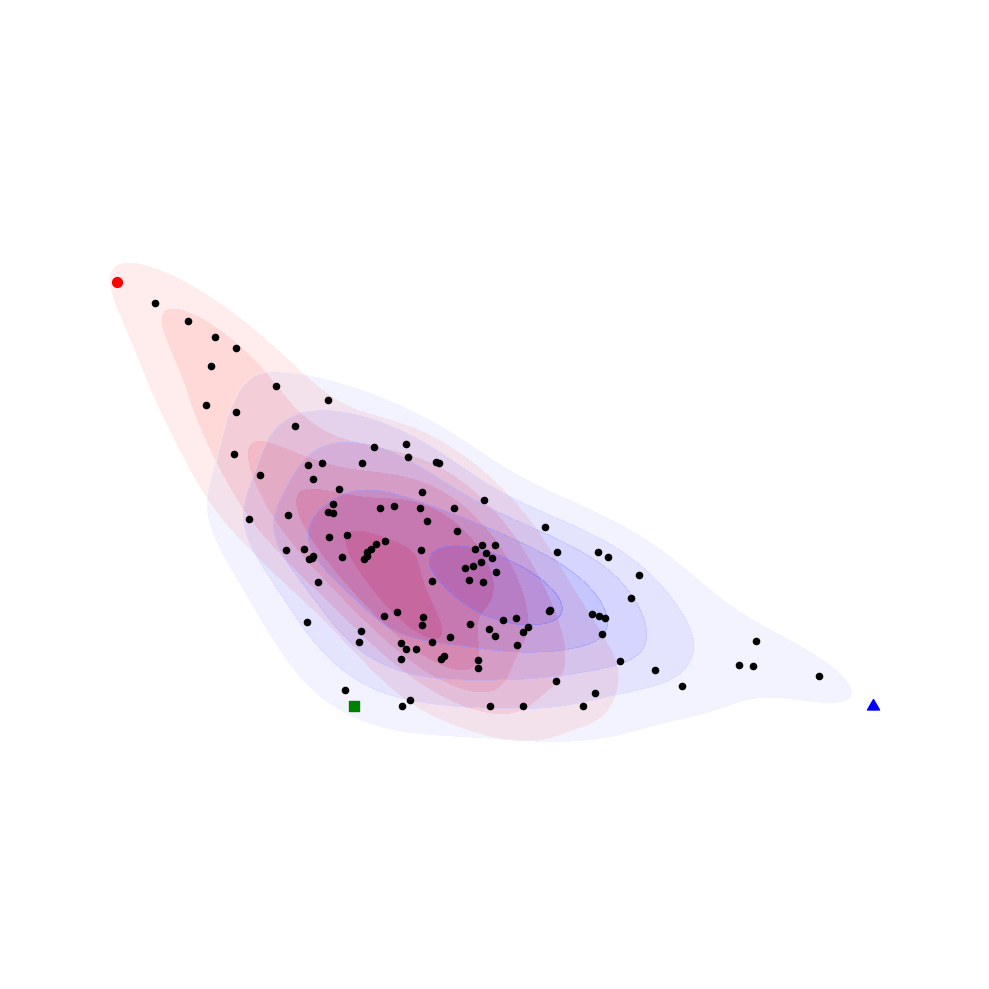

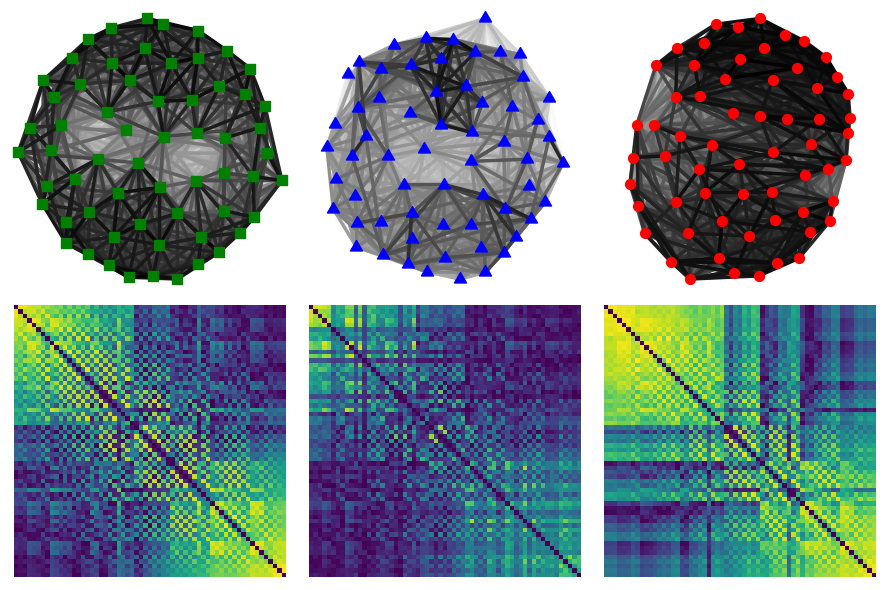

In [44]:
fig = plt.figure(figsize=(10, 10))

plt.contourf(X, Y, Z_c, levels=5, alpha=1., cmap=cmap_c, vmin=Zmax/10., vmax=Zmax)
plt.contourf(X, Y, Z_a, levels=5, alpha=.5, cmap=cmap_a, vmin=Zmax/10., vmax=Zmax)
for l, i_l in enumerate(ref_samples): plt.scatter(dataset_transformed[i_l, 0], dataset_transformed[i_l, 1], s=ref_sizes[l], c=ref_colors[l], marker=ref_markers[l], zorder=2)
plt.scatter(dataset_transformed[:, 0], dataset_transformed[:, 1], c='k', s=20)

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

fig = plt.figure(figsize=(k_ref * 3 , 6))

for (l, i_l) in enumerate(ref_samples):
    ax = plt.subplot(2, k_ref, l+1)
    plot_network(ax, dataset_without_outliers[i_l], s=ref_sizes[l], node_color=ref_colors[l], m=ref_markers[l], edge_width=2.5, x_max=1.)
    plt.axis('equal')
    plt.axis('off')

for (l, i_l) in enumerate(ref_samples):
    ax = plt.subplot(2, k_ref, k_ref+l+1)
    ax.imshow(dataset_without_outliers[i_l], cmap='viridis', interpolation='nearest', vmin=0., vmax=1.)
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()
plt.show()

# Appendix A - Illustrating Theorem 3.1 for $k=2$

In [45]:
with open('Datasets/ref_points_n=10.npy', 'rb') as f: ref_points = np.load(f)

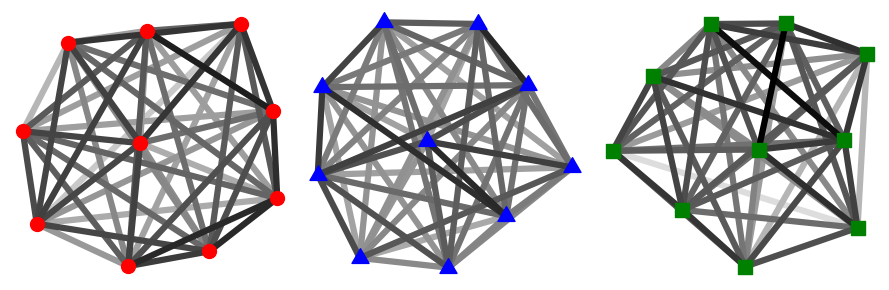

In [46]:
sizes = [100, 200, 100]
colors = ['r' , 'b', 'g']
markers = ['o', (3, 0, 0), 's']

fig = plt.figure(figsize=(9, 3))

for (i, X) in enumerate(ref_points):
    ax = plt.subplot(1, 3, i+1)
    plot_network(ax, X, s=sizes[i], node_color=colors[i], m=markers[i], x_max = np.max(ref_points))
    plt.axis('equal')
    plt.axis('off')
    
fig.tight_layout()

In [47]:
mds = MDS(n_components=2, dissimilarity='precomputed')
dist_mat = np.array([[spectral_dist(ref_points[i], ref_points[j]) for i in range(3)] for j in range(3)])
ref_coordinates = mds.fit_transform(dist_mat)
ref_spectra = np.linalg.eigvalsh(ref_points)

def is_in_the_barycentric_subspace(w):
    ineqs = [np.dot(w, ref_spectra[:, i]) <= np.dot(w, ref_spectra[:, i+1]) for i in range(ref_points.shape[1] - 1)]
    return(np.all(ineqs))

subspace = []
for w1 in np.linspace(-20., 20., 200):
    for w2 in np.linspace(-20, 20., 200):
        w = np.array([w1, w2, 1. - (w1 + w2)])
        if is_in_the_barycentric_subspace(w): subspace.append(w @ ref_coordinates)
subspace = np.array(subspace)

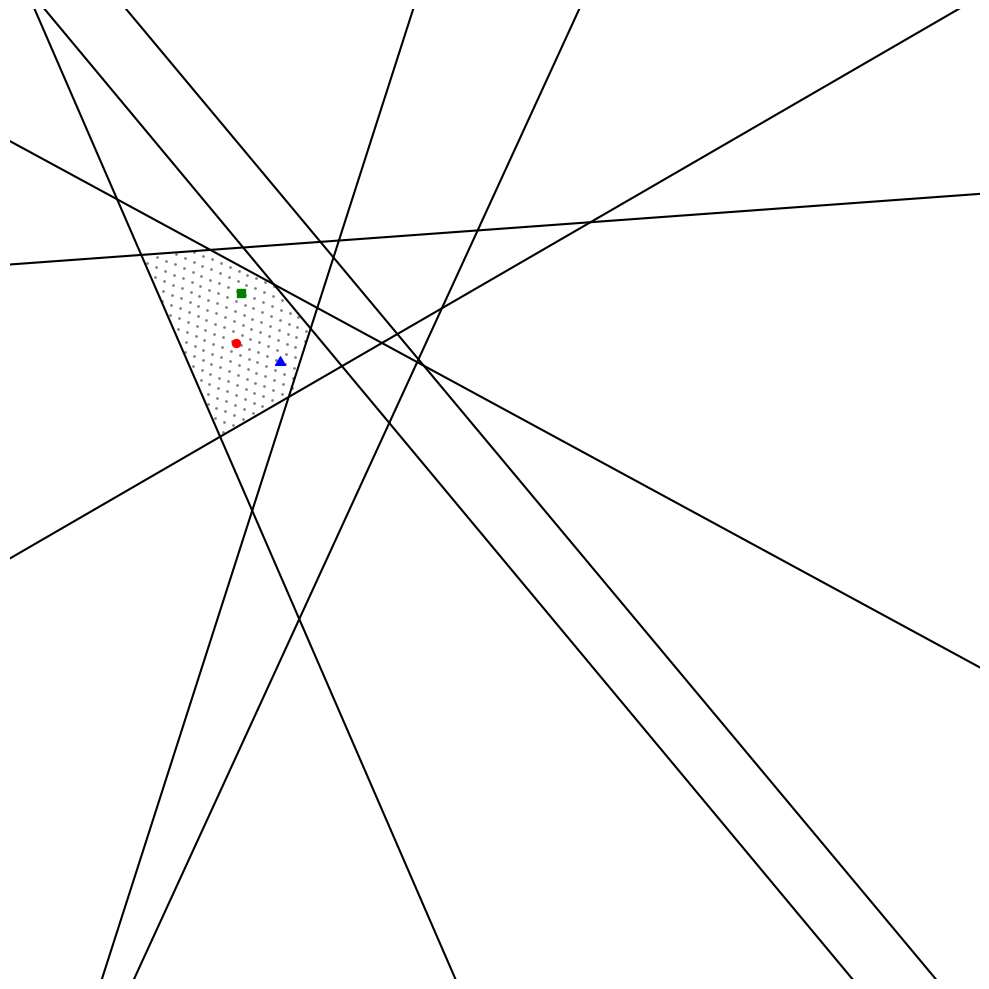

In [48]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes()

for (i, a) in enumerate(ref_coordinates): ax.scatter(a[0], a[1], s=sizes[i] / 3., c=colors[i], marker=markers[i], zorder=2)
ax.scatter(subspace[:, 0], subspace[:, 1], s=1, c='grey')
ref_coordinates_aug = np.vstack((np.transpose(ref_coordinates), np.ones(3)))
x_min, x_max = -5., 15.
for r in range(ref_points.shape[1] - 1):
    alpha = np.linalg.solve(np.transpose(ref_coordinates_aug), ref_spectra[:, r+1] - ref_spectra[:, r])
    y_min, y_max = - (alpha[0] * x_min + alpha[-1]) / alpha[1], - (alpha[0] * x_max + alpha[-1]) / alpha[1]
    ax.plot([x_min, x_max], [y_min, y_max], 'k-')

ax.set_xlim(x_min, x_max)
ax.set_ylim(-10., 5.)
plt.axis('off')
plt.tight_layout()

# Appendix B - Reference points of a clustered dataset

In [49]:
with open('Datasets/clustered.npy', 'rb') as file: dataset = np.load(file)

In [50]:
n_samples, n_nodes = dataset.shape[0], dataset.shape[1]

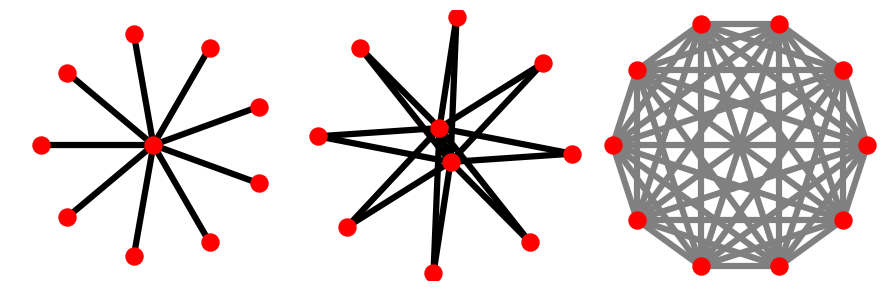

In [51]:
fig = plt.figure(figsize=(9, 3))

ax = plt.subplot(1, 3, 1)
plot_network(ax, star_graph(n_nodes), x_max=1.)
plt.axis('equal')
plt.axis('off')

ax = plt.subplot(1, 3, 2)
plot_network(ax, star_2_graph(n_nodes), x_max=1.)
plt.axis('equal')
plt.axis('off')

ax = plt.subplot(1, 3, 3)
plot_network(ax, .5 * complete_graph(n_nodes), x_max=1.)
plt.axis('equal')
plt.axis('off')

fig.tight_layout()

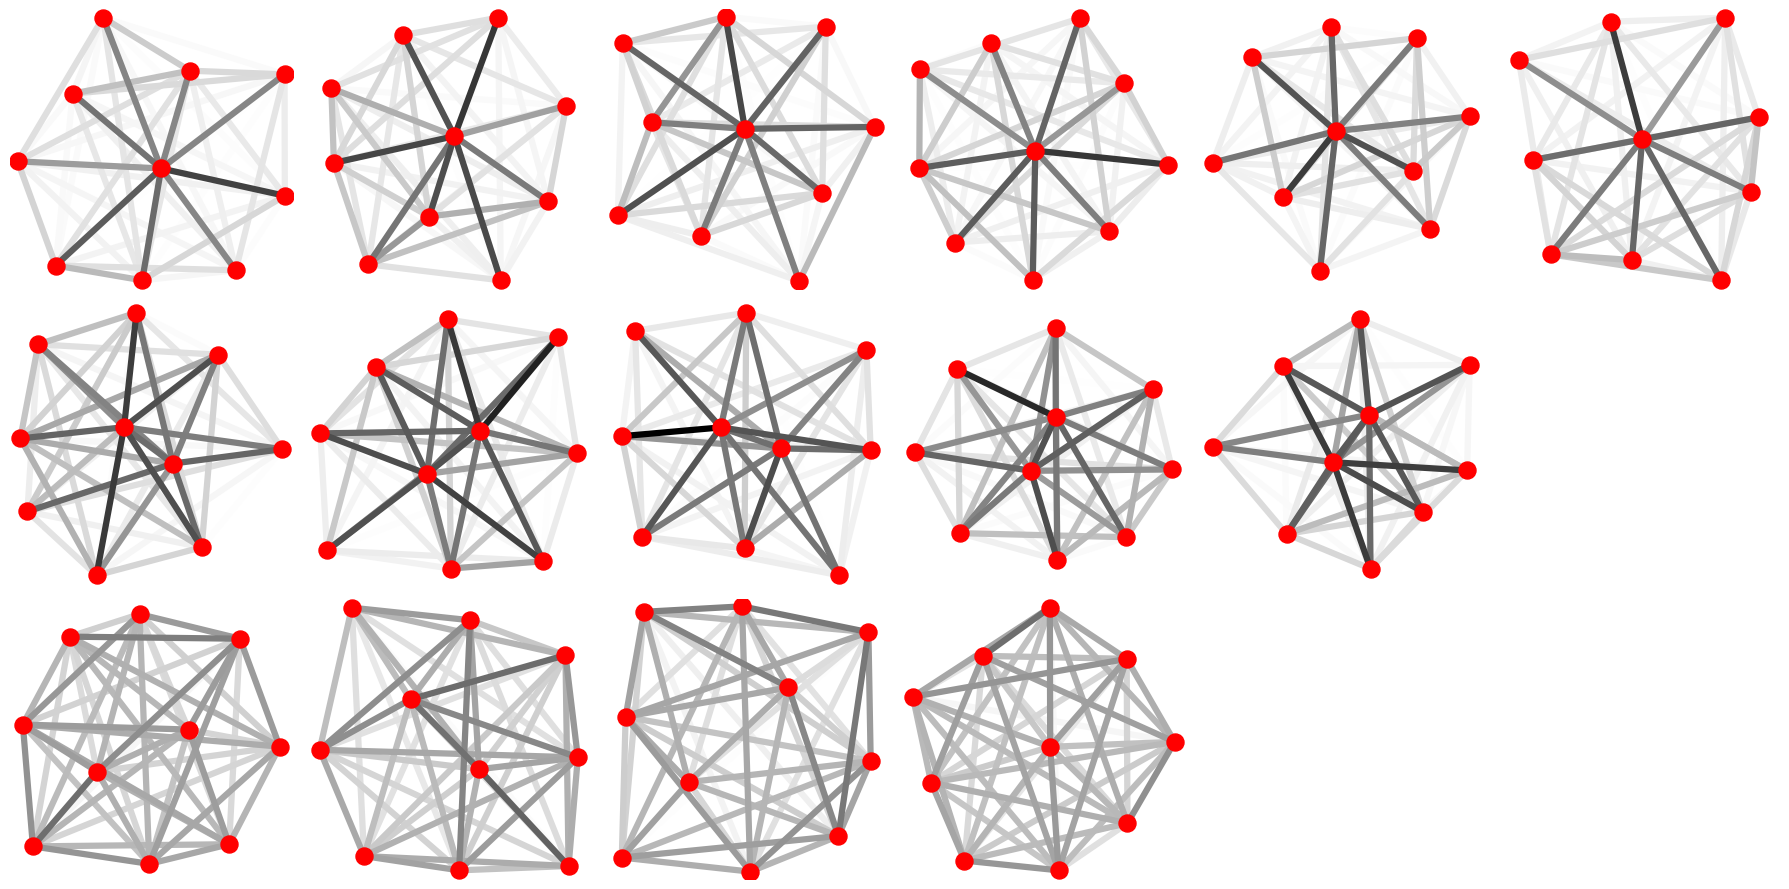

In [52]:
fig = plt.figure(figsize=(18, 9))

for (i, X) in enumerate(dataset):
    if i < 11: ax = plt.subplot(3, 6, i+1)
    else : ax = plt.subplot(3, 6, i+2)
    plot_network(ax, X, x_max=np.max(dataset))
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()

In [53]:
bsa = NetBSA(n_nodes=n_nodes, k_ref=3)

In [54]:
ref_samples_seq, weights_seq, total_error_seq = bsa._forward_bsa(dataset)

1
2
3
4
5
6
7
8
9
10
11
12
13
14


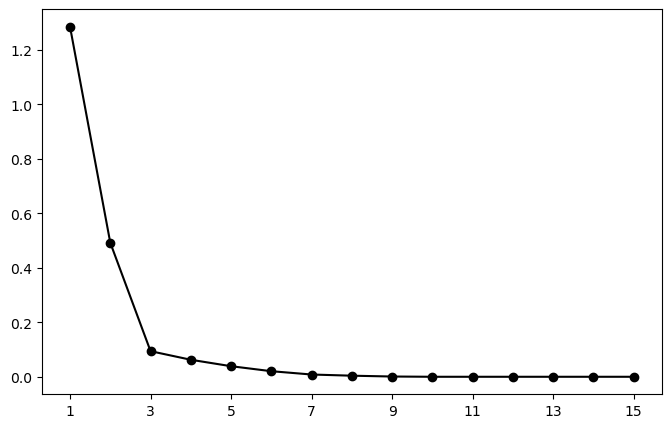

In [55]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.plot(np.arange(1, len(total_error_seq)+1), [max(1E-12, e) for e in np.array(total_error_seq) / n_samples], 'ko-')
xticks = np.arange(1, len(total_error_seq)+1, 2)
ax.set_xticks(xticks);

In [56]:
ref_samples_seq, weights_seq, total_error_seq = bsa._backward_bsa(dataset, ref_samples_init=ref_samples_seq[-1])

15
14
13
12
11
10
9
8
7
6
5
4
3
2


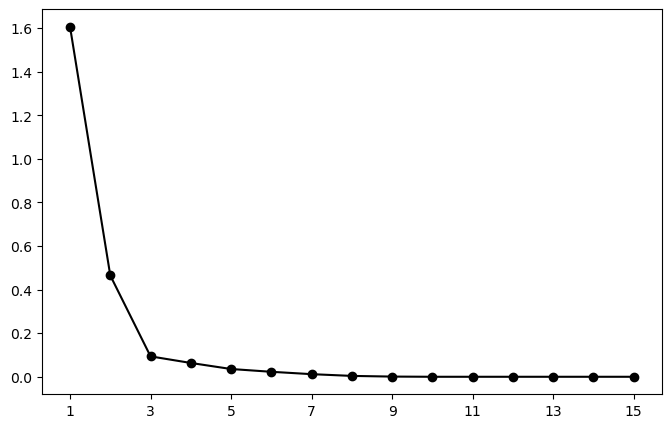

In [57]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.plot(np.arange(1, len(total_error_seq)+1), [max(1E-12, e) for e in np.array(total_error_seq) / n_samples], 'ko-')
xticks = np.arange(1, len(total_error_seq)+1, 2)
ax.set_xticks(xticks);

In [58]:
k_ref = 3

In [59]:
ref_samples = ref_samples_seq[k_ref-1]
weights = weights_seq[k_ref-1]
total_error = total_error_seq[k_ref-1]
print("reference networks:", [int(i) for i in ref_samples])
print("mse:", total_error / n_samples)

reference networks: [6, 14, 3]
mse: 0.09364007002119974


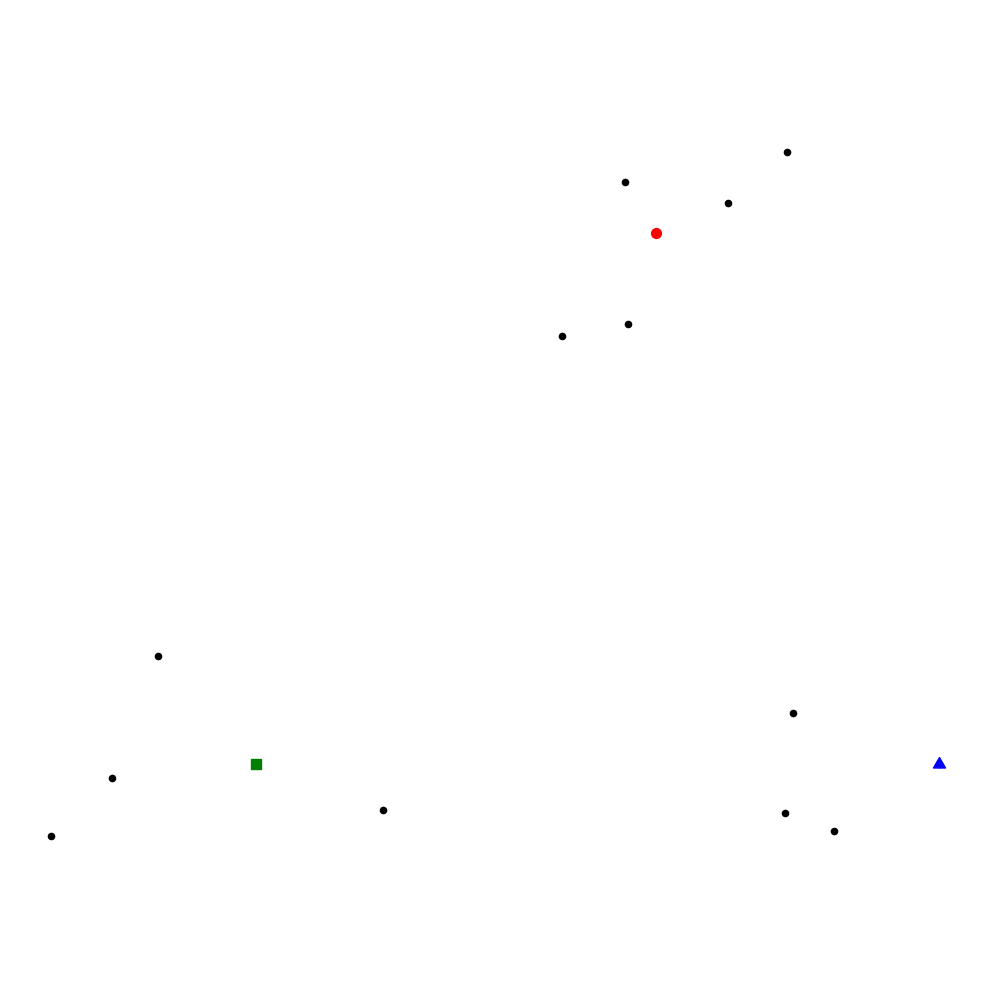

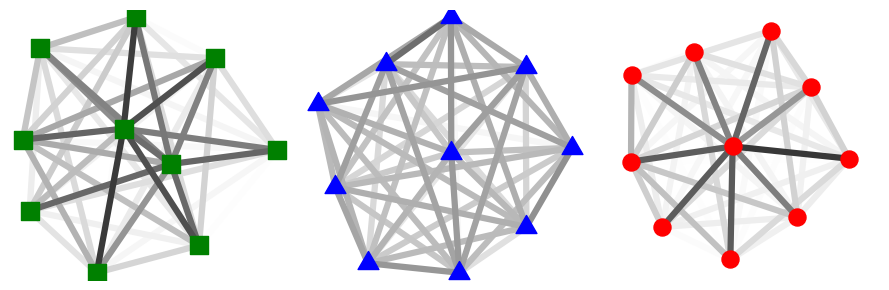

In [60]:
dataset_transformed = bsa._visualize_2d(dataset, dataset[ref_samples], weights)

ref_colors = ['g', 'b', 'r']
ref_markers = ['s', (3, 0, 0), 'o']
ref_sizes = [150, 300, 150]

fig = plt.figure(figsize=(10, 10))

for l, i_l in enumerate(ref_samples): plt.scatter(dataset_transformed[i_l, 0], dataset_transformed[i_l, 1], s=ref_sizes[l] / 3., c=ref_colors[l], marker=ref_markers[l], zorder=2)
plt.scatter(dataset_transformed[:, 0], dataset_transformed[:, 1], c='k', s=20)

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

fig = plt.figure(figsize=(k_ref * 3, 3))

for (l, i_l) in enumerate(ref_samples):
    ax = plt.subplot(1, k_ref, l+1)
    plot_network(ax, dataset[i_l], s=ref_sizes[l], node_color=ref_colors[l], m=ref_markers[l], x_max=np.max(dataset))
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()

In [61]:
ref_samples_seq, weights_seq, total_error_seq = bsa._forward_convex_bsa(dataset)

2
3
4
5
6
7
8
9
10
11
12
13
14


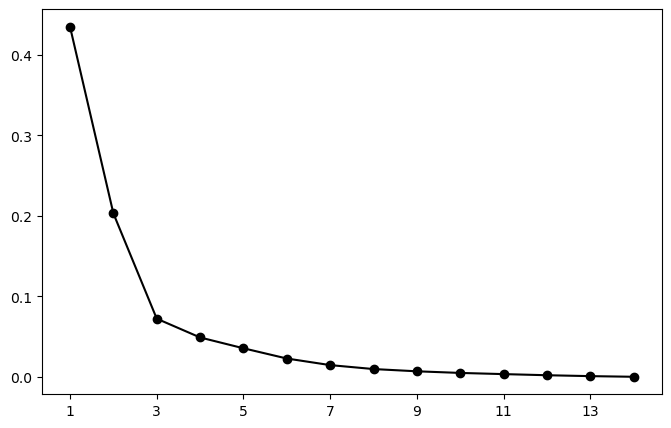

In [62]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.plot(np.arange(1, len(total_error_seq)+1), [max(1E-12, e) for e in np.array(total_error_seq) / n_samples], 'ko-')
xticks = np.arange(1, len(total_error_seq)+1, 2)
ax.set_xticks(xticks);

In [63]:
ref_samples_seq, weights_seq, total_error_seq = bsa._backward_convex_bsa(dataset, ref_samples_init=ref_samples_seq[-1])

15
14
13
12
11
10
9
8
7
6
5
4
3
2


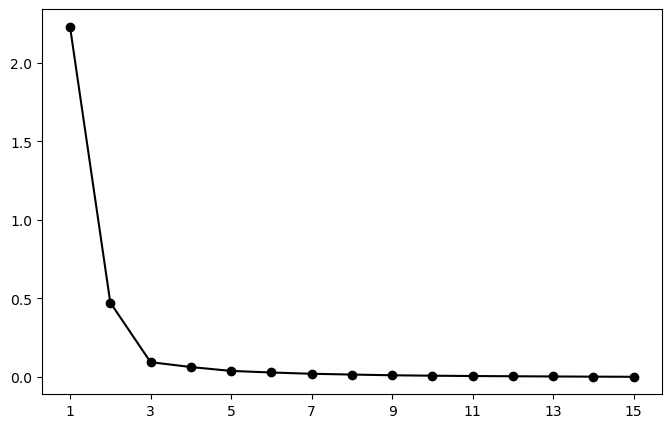

In [64]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes()
ax.plot(np.arange(1, len(total_error_seq)+1), [max(1E-12, e) for e in np.array(total_error_seq) / n_samples], 'ko-')
xticks = np.arange(1, len(total_error_seq)+1, 2)
ax.set_xticks(xticks);

In [65]:
k_ref = 3

In [66]:
ref_samples = ref_samples_seq[k_ref-1]
weights = weights_seq[k_ref-1]
total_error = total_error_seq[k_ref-1]
print("reference networks:", [int(i) for i in ref_samples])
print("mse:", total_error / n_samples)

reference networks: [0, 10, 11]
mse: 0.09320958070998722


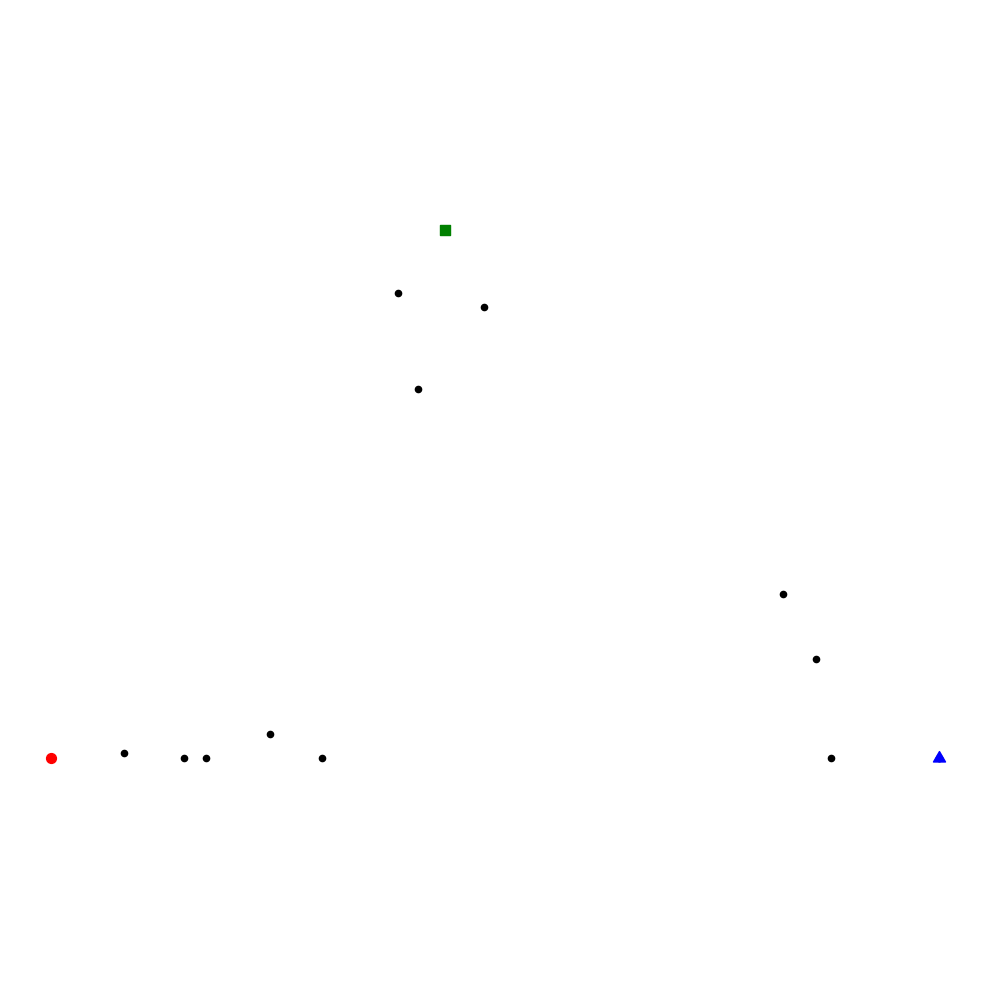

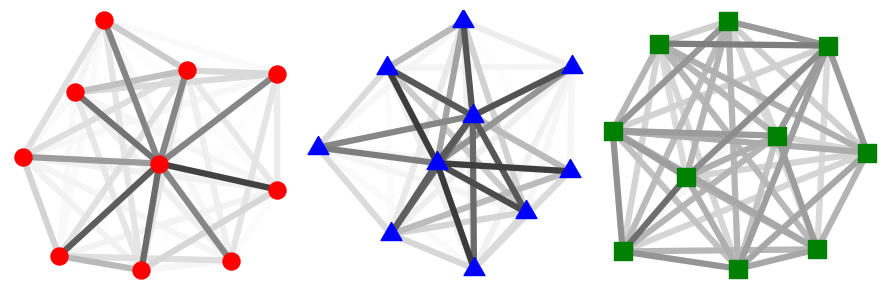

In [67]:
dataset_transformed = bsa._visualize_2d(dataset, dataset[ref_samples], weights)

ref_colors = ['r', 'b', 'g']
ref_markers = ['o', (3, 0, 0), 's']
ref_sizes = [150, 300, 150]

fig = plt.figure(figsize=(10, 10))

for l, i_l in enumerate(ref_samples): plt.scatter(dataset_transformed[i_l, 0], dataset_transformed[i_l, 1], s=ref_sizes[l] / 3., c=ref_colors[l], marker=ref_markers[l], zorder=2)
plt.scatter(dataset_transformed[:, 0], dataset_transformed[:, 1], c='k', s=20)

plt.axis('equal')
plt.axis('off')
fig.tight_layout()

fig = plt.figure(figsize=(k_ref * 3, 3))

for (l, i_l) in enumerate(ref_samples):
    ax = plt.subplot(1, k_ref, l+1)
    plot_network(ax, dataset[i_l], s=ref_sizes[l], node_color=ref_colors[l], m=ref_markers[l], x_max=np.max(dataset))
    plt.axis('equal')
    plt.axis('off')

fig.tight_layout()